# Chapter 6: Extending Hypothesis Testing


In this notebook, we extend hypothesis testing beyond means.

We will study:
- hypothesis tests for proportions
- tests for variability
- chi-square tests
- ANOVA
- one-sided confidence intervals


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## Testing Proportions

In [2]:
# Suppose 44 out of 200 users clicked an advertisement

clicks = 44
sample_size = 200

sample_proportion = clicks / sample_size

print("Sample proportion:", sample_proportion)


Sample proportion: 0.22


In [3]:
# Hypothesized click rate

p_0 = 0.20

# Standard error for proportions

standard_error = np.sqrt((p_0 * (1 - p_0)) / sample_size)

print("Standard error:", round(standard_error, 4))


Standard error: 0.0283


In [4]:
# Compute the z-score

z_score = (sample_proportion - p_0) / standard_error

print("z-score:", round(z_score, 2))


z-score: 0.71


In [5]:
# Right-tailed p-value

p_value = 1 - stats.norm.cdf(z_score)

print("p-value:", round(p_value, 4))


p-value: 0.2398


In [7]:
# Null hypothesis:
# H0: p = 0.20

# Alternative hypothesis:
# Ha: p > 0.20

print("H0: p = 0.20")
print("Ha: p > 0.20")


H0: p = 0.20
Ha: p > 0.20


In [6]:
# Decision at alpha = 0.05

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Fail to reject H0


## Visualizing the z-Distribution

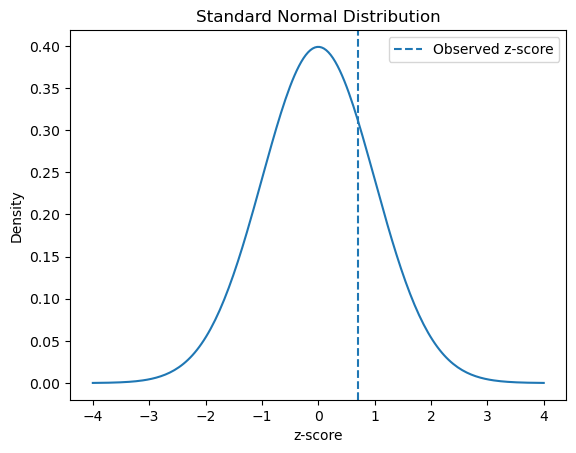

In [8]:
# Create values for the horizontal axis

x = np.linspace(-4, 4, 200)

# Standard normal density

y = stats.norm.pdf(x)

plt.plot(x, y)

plt.axvline(z_score, linestyle='--', label='Observed z-score')

plt.title("Standard Normal Distribution")

plt.xlabel("z-score")
plt.ylabel("Density")

plt.legend()

plt.show()


## Two-Tailed Proportion Test

In [9]:
# Example: 212 out of 400 people support a candidate

successes = 212
sample_size = 400

sample_proportion = successes / sample_size

p_0 = 0.50

standard_error = np.sqrt((p_0 * (1 - p_0)) / sample_size)

z_score = (sample_proportion - p_0) / standard_error

# Two-tailed p-value

p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Sample proportion:", sample_proportion)
print("z-score:", round(z_score, 2))
print("p-value:", round(p_value, 4))


Sample proportion: 0.53
z-score: 1.2
p-value: 0.2301


## Testing Variability

In [10]:
# Wind power stability example

sample_std = 7.2
claimed_std = 5
sample_size = 20


In [11]:
# Compute the chi-square statistic

chi_square = ((sample_size - 1) * (sample_std ** 2)) / (claimed_std ** 2)

print("Chi-square statistic:", round(chi_square, 2))


Chi-square statistic: 39.4


In [12]:
# Degrees of freedom

df = sample_size - 1

print("Degrees of freedom:", df)


Degrees of freedom: 19


In [13]:
# Right-tailed p-value

p_value = 1 - stats.chi2.cdf(chi_square, df)

print("p-value:", round(p_value, 4))


p-value: 0.0039


In [14]:
# Null hypothesis:
# H0: sigma = 5

# Alternative hypothesis:
# Ha: sigma > 5

print("H0: sigma = 5")
print("Ha: sigma > 5")

H0: sigma = 5
Ha: sigma > 5


In [15]:
# Decision at alpha = 0.05

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Visualizing the Chi-Square Distribution

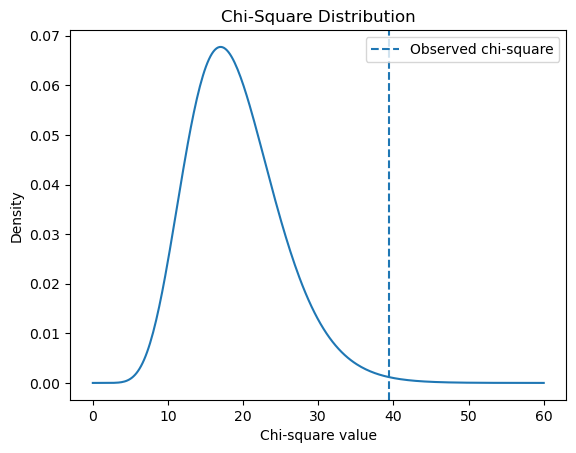

In [16]:
# Create values for the horizontal axis

x = np.linspace(0, 60, 300)

# Chi-square density

y = stats.chi2.pdf(x, df=df)

plt.plot(x, y)

plt.axvline(chi_square, linestyle='--', label='Observed chi-square')

plt.title("Chi-Square Distribution")

plt.xlabel("Chi-square value")
plt.ylabel("Density")

plt.legend()

plt.show()


# Appendix: ANOVA

## Comparing Multiple Groups

In [17]:
# Exam scores for three teaching methods

method_A = [78, 80, 82]
method_B = [79, 81, 83]
method_C = [88, 90, 92]


In [18]:
# Compute group means

print("Method A mean:", np.mean(method_A))
print("Method B mean:", np.mean(method_B))
print("Method C mean:", np.mean(method_C))


Method A mean: 80.0
Method B mean: 81.0
Method C mean: 90.0


In [19]:
# Perform one-way ANOVA

F_statistic, p_value = stats.f_oneway(
    method_A,
    method_B,
    method_C
)

print("F-statistic:", round(F_statistic, 2))
print("p-value:", round(p_value, 6))


F-statistic: 22.75
p-value: 0.001581


In [20]:
# Null hypothesis:
# H0: all group means are equal

# Alternative hypothesis:
# Ha: at least one group mean is different

print("H0: mu_A = mu_B = mu_C")
print("Ha: at least one mean differs")

H0: mu_A = mu_B = mu_C
Ha: at least one mean differs


In [21]:
# Decision at alpha = 0.05

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Visualizing Group Scores

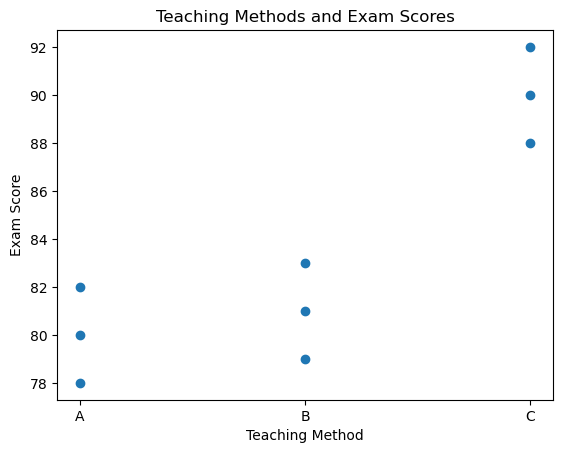

In [22]:
# Create labels for the groups

groups = ["A", "A", "A",
          "B", "B", "B",
          "C", "C", "C"]

# Combine all scores

scores = method_A + method_B + method_C

plt.scatter(groups, scores)

plt.title("Teaching Methods and Exam Scores")

plt.xlabel("Teaching Method")
plt.ylabel("Exam Score")

plt.show()
